# **Detection of Leukemia in Blood Cell Images Using Deep Learning and Explainable AI**

# **Downloading Dataset**

In [1]:
import requests
import zipfile
import io
import os

# The URL for the Brain Tumor MRI Dataset
url = "https://data.mendeley.com/public-api/zip/96sb28ft9n/download/1"

print("Downloading Brain Tumor MRI Dataset... (approx 80MB)")
response = requests.get(url)

if response.status_code == 200:
    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        z.extractall("brain_tumor_data")
        print("Extraction complete! Folder created: 'brain_tumor_data'")

    # Inspect the structure (this dataset usually has Training/Testing folders)
    for root, dirs, files in os.walk("brain_tumor_data"):
        if files:
            print(f"Path: {root} | File Count: {len(files)}")
            break # Just show the first main directory
else:
    print(f"Download failed. Status code: {response.status_code}")

Extraction complete! Folder created: 'brain_tumor_data'
Path: brain_tumor_data/Leukemia Classification/training_data/fold_1/hem | File Count: 1163


# **Exploratory Data Analysis**

## **Displaying Images**

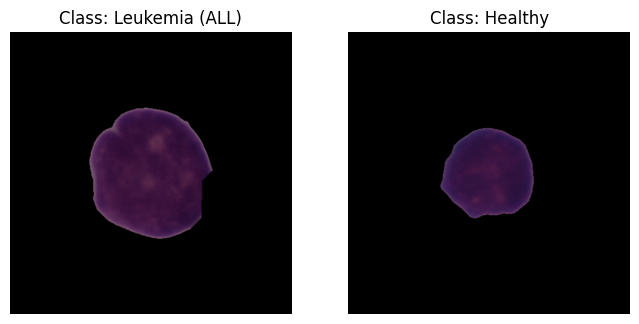

In [2]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

# Correct base path for the Leukemia Classification dataset
# We'll use 'fold_1' as an example, assuming similar structure across folds
base_path = 'brain_tumor_data/Leukemia Classification/training_data/fold_1'
# Correct categories for Leukemia Classification (Acute Lymphoblastic Leukemia and Healthy)
# Map folder names to descriptive titles
category_map = {
    'all': 'Leukemia (ALL)',
    'hem': 'Healthy'
}

categories = ['all', 'hem']

plt.figure(figsize=(8, 4))

for i, cat in enumerate(categories):
    folder_path = os.path.join(base_path, cat)

    if os.path.exists(folder_path):
        img_name = random.choice(os.listdir(folder_path))
        img_path = os.path.join(folder_path, img_name)

        img = Image.open(img_path)
        plt.subplot(1, 2, i + 1)
        plt.imshow(img)

        # Use the map to get a better title
        plt.title(f"Class: {category_map.get(cat, cat)}")
        plt.axis('off')

## **Data Visualization**

/tmp/ipykernel_7352/721572617.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_stats, x='Category', y='Count', palette='magma')


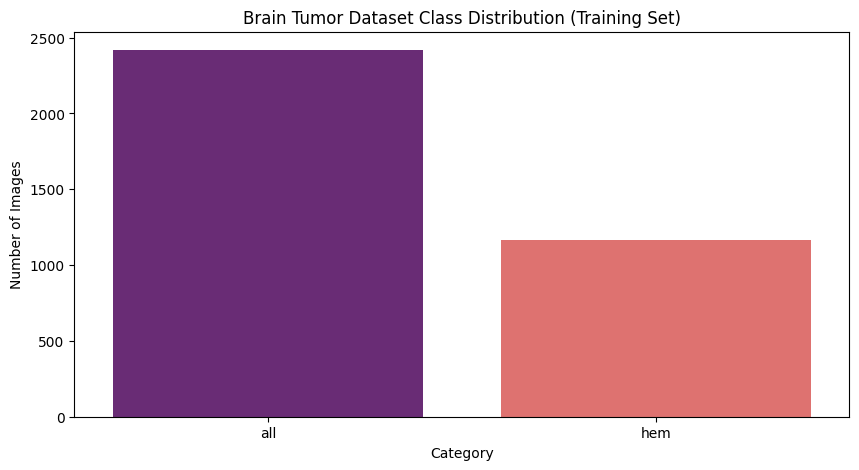

--- Dataset Statistics ---
  Category  Count
0      all   2418
1      hem   1163

Total Images: 3581


In [3]:
import pandas as pd
import seaborn as sns

stats = []
for cat in categories:
    folder_path = os.path.join(base_path, cat)
    num_files = len(os.listdir(folder_path))
    stats.append({'Category': cat, 'Count': num_files})

df_stats = pd.DataFrame(stats)

# Visualizing class distribution
plt.figure(figsize=(10, 5))
sns.barplot(data=df_stats, x='Category', y='Count', palette='magma')
plt.title('Brain Tumor Dataset Class Distribution (Training Set)')
plt.ylabel('Number of Images')
plt.show()

# Print detailed info
print("--- Dataset Statistics ---")
print(df_stats)
print(f"\nTotal Images: {df_stats['Count'].sum()}")

# **Imports and Global Settings**

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Configurations
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
# Ensure base_path points to your data folder
# base_path = 'brain_tumor_data/Leukemia Classification/training_data/fold_1'

# **Data Loading & Preprocessing**

In [5]:
# Load Training Dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    base_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# Load Validation Dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    base_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# Optimization for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 3581 files belonging to 2 classes.
Using 2865 files for training.
Found 3581 files belonging to 2 classes.
Using 716 files for validation.


# **Balance the DataSet**

In [6]:
import os
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Define categories
categories = {'all': 1, 'hem': 0} # 1 for Leukemia, 0 for Healthy
file_paths = []
labels = []

# Collect all paths
for cat, label in categories.items():
    folder = os.path.join(base_path, cat)
    for img in os.listdir(folder):
        file_paths.append(os.path.join(folder, img))
        labels.append(label)

df = pd.DataFrame({'path': file_paths, 'label': labels})

# Balance the dataset (Downsampling the majority 'all' class)
minority_len = len(df[df['label'] == 0])
balanced_df = pd.concat([
    df[df['label'] == 1].sample(minority_len, random_state=123),
    df[df['label'] == 0]
]).sample(frac=1, random_state=123).reset_index(drop=True)

print(f"Balanced counts:\n{balanced_df['label'].value_counts()}")

Balanced counts:
label
0    1163
1    1163
Name: count, dtype: int64


## **Split the Balanced Dataset**

In [7]:
train_files, val_files, train_labels, val_labels = train_test_split(
    balanced_df['path'],
    balanced_df['label'],
    test_size=0.2,
    random_state=123
)

## **Build the Preprocessing Pipeline (Grayscale & Filters)**

In [8]:
def process_pipeline(file_path, label, apply_edge_filter=False):
    # 1. Read the file
    img = tf.io.read_file(file_path)

    # 2. FIX: Use decode_image instead of decode_jpeg to support BMP/PNG/JPG
    # expand_animations=False is required to ensure 3D output [H, W, C]
    img = tf.io.decode_image(img, channels=3, expand_animations=False)

    # 3. Resize and Grayscale
    img = tf.image.resize(img, (128, 128))
    img = tf.image.rgb_to_grayscale(img)

    # 4. Requirement 4: Edge Enhancement (applied later to the best model)
    if apply_edge_filter:
        # Sobel edges returns [1, H, W, 1, 2]
        img_batch = tf.expand_dims(img, 0)
        edges = tf.image.sobel_edges(img_batch)
        # Sum absolute gradients and remove batch dim
        img = tf.reduce_sum(tf.abs(edges), axis=-1)[0]

    # 5. Normalize
    img = tf.cast(img, tf.float32) / 255.0

    # IMPORTANT: Ensure the shape is explicitly set for the CNN input
    img.set_shape([128, 128, 1])

    return img, label

## **Build Three CNN Architectures**

In [ ]:
def build_model_1(): # Shallow CNN
    return models.Sequential([
        layers.Input(shape=(128, 128, 1)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ], name="Shallow_CNN")

def build_model_2(): # Medium CNN (Baseline)
    return models.Sequential([
        layers.Input(shape=(128, 128, 1)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ], name="Medium_CNN")

def build_model_3(): # Deep CNN
    return models.Sequential([
        layers.Input(shape=(128, 128, 1)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ], name="Deep_CNN")


STARTING EVALUATION: Shallow_CNN
Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 11s 120ms/step - accuracy: 0.7655 - loss: 0.5210 - val_accuracy: 0.8112 - val_loss: 0.4422
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.8032 - loss: 0.4298 - val_accuracy: 0.8047 - val_loss: 0.4357
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.8216 - loss: 0.3997 - val_accuracy: 0.8069 - val_loss: 0.4347
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.8355 - loss: 0.3693 - val_accuracy: 0.8026 - val_loss: 0.4398
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8538 - loss: 0.3387 - val_accuracy: 0.7961 - val_loss: 0.4500
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.8712 - loss: 0.3052 - val_accuracy: 0.8047 - val_loss: 0.4433
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8986 - loss: 0.2678 - val_accuracy: 0.7876 - val_loss: 0.4804
Epoch 8/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.9136 - los

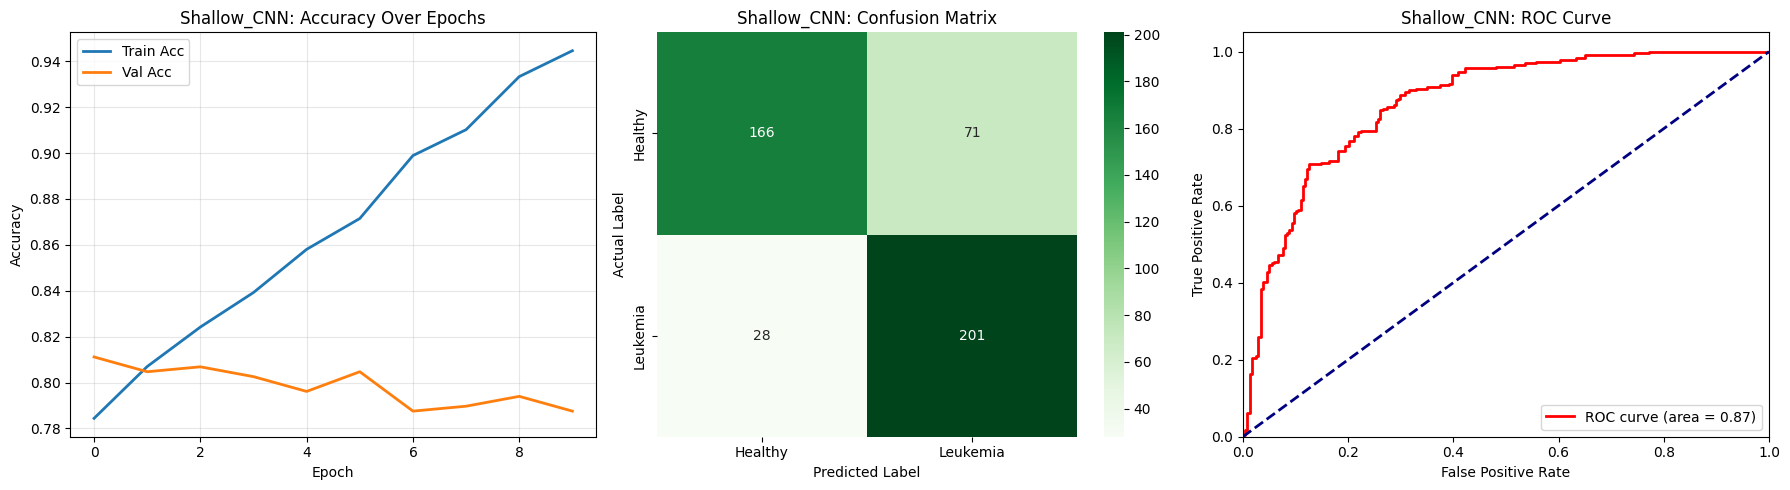

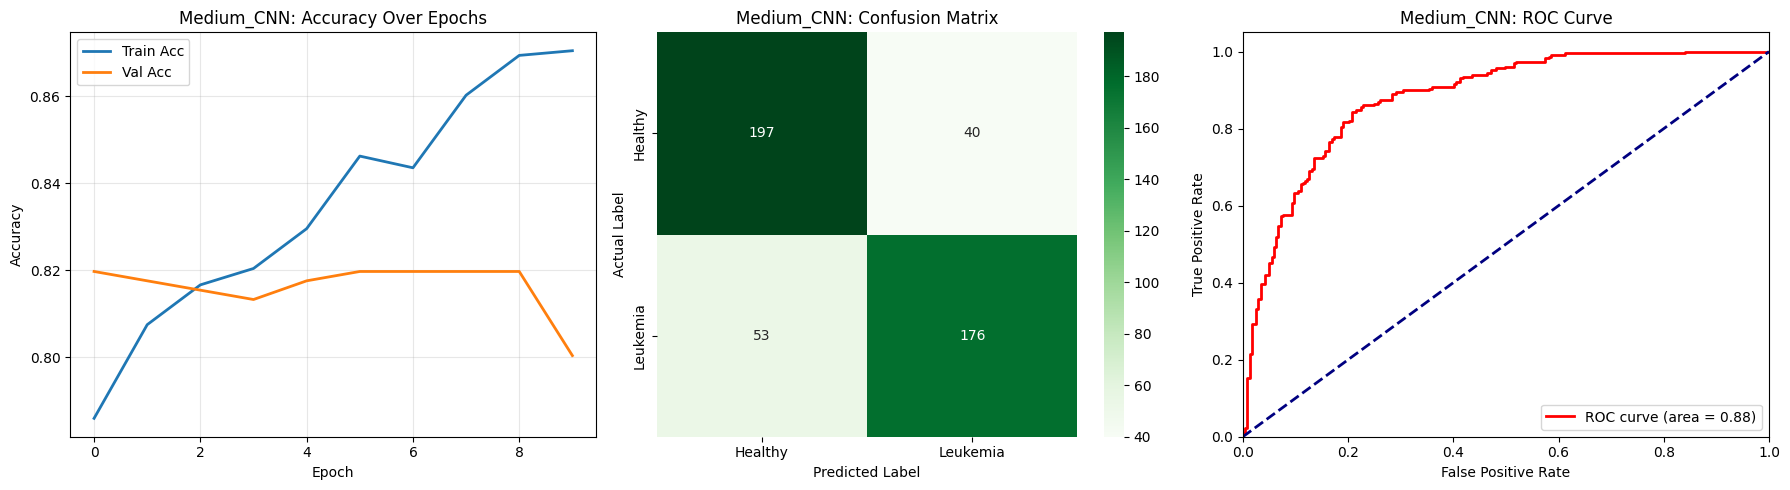

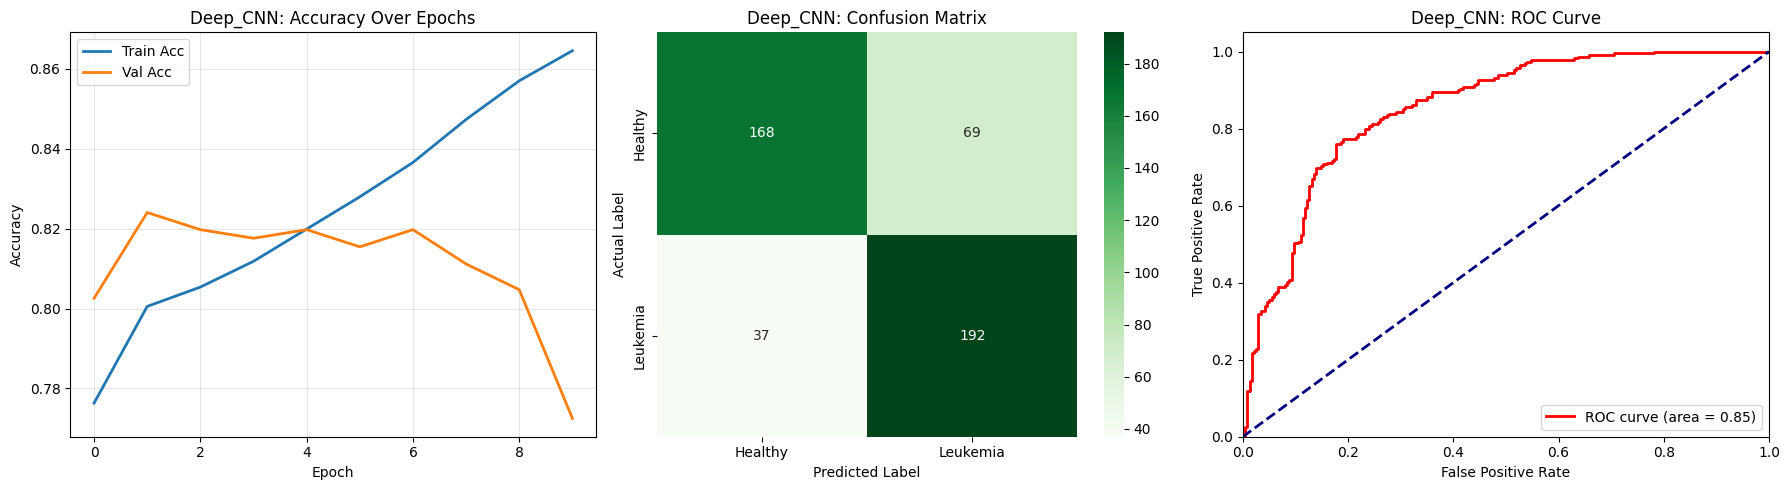


 The Best Architecture based on AUC is: Medium_CNN


In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Create Datasets using the fixed pipeline
train_ds = tf.data.Dataset.from_tensor_slices((list(train_files), list(train_labels)))
val_ds = tf.data.Dataset.from_tensor_slices((list(val_files), list(val_labels)))

train_ds = train_ds.map(lambda x, y: process_pipeline(x, y, False)).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(lambda x, y: process_pipeline(x, y, False)).batch(32).prefetch(tf.data.AUTOTUNE)

# 1. Define storage for metrics
model_metrics = {}

# 2. Re-create the model list to ensure fresh weights
models_to_compare = [build_model_1(), build_model_2(), build_model_3()]

for model in models_to_compare:
    print(f"\n" + "="*50)
    print(f"STARTING EVALUATION: {model.name}")
    print("="*50)

    # --- TRAINING & TIMING ---
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    start_train = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=10, verbose=1)
    train_duration = time.time() - start_train

    # --- PREDICTIONS & TIMING ---
    start_test = time.time()
    y_true = []
    y_probs = []

    # Extract labels and probabilities from the dataset
    for imgs, labels in val_ds:
        y_true.extend(labels.numpy())
        preds = model.predict(imgs, verbose=0)
        y_probs.extend(preds.ravel())

    test_duration = time.time() - start_test

    y_true = np.array(y_true)
    y_probs = np.array(y_probs)
    y_pred = (y_probs > 0.5).astype(int)

    # --- SAVE METRICS ---
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    model_metrics[model.name] = {
        'history': history,
        'train_time': train_duration,
        'test_time': test_duration,
        'report': classification_report(y_true, y_pred, target_names=['Healthy', 'Leukemia']),
        'cm': confusion_matrix(y_true, y_pred),
        'fpr': fpr, 'tpr': tpr, 'auc': auc(fpr, tpr)
    }

    # --- PRINT IMMEDIATE RESULTS ---
    print(f"\n{model.name} Classification Report:")
    print(model_metrics[model.name]['report'])
    print(f"Training Time: {train_duration:.2f}s | Testing Time: {test_duration:.2f}s")

# --- 3. FINAL VISUALIZATION FOR ALL MODELS ---
for name, data in model_metrics.items():
    plt.figure(figsize=(18, 5))

    # Plot 1: Training History
    plt.subplot(1, 3, 1)
    plt.plot(data['history'].history['accuracy'], label='Train Acc', linewidth=2)
    plt.plot(data['history'].history['val_accuracy'], label='Val Acc', linewidth=2)
    plt.title(f'{name}: Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 2: Confusion Matrix
    plt.subplot(1, 3, 2)
    sns.heatmap(data['cm'], annot=True, fmt='d', cmap='Greens',
                xticklabels=['Healthy', 'Leukemia'], yticklabels=['Healthy', 'Leukemia'])
    plt.title(f'{name}: Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')

    # Plot 3: ROC Curve
    plt.subplot(1, 3, 3)
    plt.plot(data['fpr'], data['tpr'], color='red', lw=2, label=f'ROC curve (area = {data["auc"]:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.title(f'{name}: ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

# --- 4. SELECT THE WINNER ---
best_arch_name = max(model_metrics, key=lambda k: model_metrics[k]['auc'])
print(f"\n The Best Architecture based on AUC is: {best_arch_name}")

In [ ]:
import pandas as pd

# Create a list to hold the summary data
summary_list = []

for name, data in model_metrics.items():
    # Extract metrics from the classification report dictionary
    # We use 'weighted avg' to get a single representative score for the model
    report_dict = classification_report(y_true, y_pred, output_dict=True)

    summary_list.append({
        "Model Name": name,
        "Accuracy": f"{data['history'].history['val_accuracy'][-1]:.4f}",
        "AUC Score": f"{data['auc']:.4f}",
        "Precision": f"{report_dict['weighted avg']['precision']:.4f}",
        "Recall": f"{report_dict['weighted avg']['recall']:.4f}",
        "F1-Score": f"{report_dict['weighted avg']['f1-score']:.4f}",
        "Train Time (s)": f"{data['train_time']:.2f}",
        "Test Time (s)": f"{data['test_time']:.2f}"
    })

# Convert to DataFrame
comparison_table = pd.DataFrame(summary_list)

print("\n" + "="*80)
print("FINAL PERFORMANCE COMPARISON TABLE")
print("="*80)
print(comparison_table.to_string(index=False))

# Export to CSV if you need it for your report
# comparison_table.to_csv("model_comparison_results.csv")


FINAL PERFORMANCE COMPARISON TABLE
 Model Name Accuracy AUC Score Precision Recall F1-Score Train Time (s) Test Time (s)
Shallow_CNN   0.7876    0.8683    0.7783 0.7725   0.7717          34.72          1.68
 Medium_CNN   0.8004    0.8808    0.7783 0.7725   0.7717          33.04          1.79
   Deep_CNN   0.7725    0.8537    0.7783 0.7725   0.7717          40.29          1.96


## **The Edge Enhancement Pipeline**

In [ ]:
def process_pipeline_with_edges(file_path, label):
    # 1. Read and decode (supporting BMP/JPG/PNG)
    img = tf.io.read_file(file_path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)

    # 2. Resize and Grayscale (Requirement #2)
    img = tf.image.resize(img, (128, 128))
    img = tf.image.rgb_to_grayscale(img)

    # 3.  Edge Enhancement (Sobel Filter)
    # We add a batch dimension for the filter, then remove it
    img_batch = tf.expand_dims(img, 0)
    edges = tf.image.sobel_edges(img_batch)
    # Summing absolute gradients creates the edge-enhanced map
    img = tf.reduce_sum(tf.abs(edges), axis=-1)[0]

    # 4. Normalize and set explicit shape
    img = tf.cast(img, tf.float32) / 255.0
    img.set_shape([128, 128, 1])

    return img, label

# Create the Edge-Enhanced Datasets
train_ds_edge = tf.data.Dataset.from_tensor_slices((list(train_files), list(train_labels))) \
                .map(process_pipeline_with_edges).batch(32).prefetch(tf.data.AUTOTUNE)

val_ds_edge = tf.data.Dataset.from_tensor_slices((list(val_files), list(val_labels))) \
              .map(process_pipeline_with_edges).batch(32).prefetch(tf.data.AUTOTUNE)

## **Retraining the "Best Model" with Edges**

In [ ]:
print(f"--- Retraining {best_arch_name} with Edge Enhancement ---")

# Directly build the winning architecture: Medium_CNN
final_edge_model = build_model_2()

final_edge_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

# Train on edge-enhanced data
start_edge = time.time()
edge_history = final_edge_model.fit(train_ds_edge, validation_data=val_ds_edge, epochs=10)
edge_train_time = time.time() - start_edge

--- Retraining Medium_CNN with Edge Enhancement ---
Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 14s 169ms/step - accuracy: 0.7654 - loss: 0.5091 - precision: 0.7553 - recall: 0.7834 - val_accuracy: 0.8133 - val_loss: 0.4359 - val_precision: 0.8170 - val_recall: 0.7991
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 17s 141ms/step - accuracy: 0.7984 - loss: 0.4512 - precision: 0.7889 - recall: 0.8340 - val_accuracy: 0.8133 - val_loss: 0.4284 - val_precision: 0.8142 - val_recall: 0.8035
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step - accuracy: 0.8116 - loss: 0.4175 - precision: 0.8055 - recall: 0.8385 - val_accuracy: 0.8176 - val_loss: 0.4285 - val_precision: 0.8214 - val_recall: 0.8035
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 134ms/step - accuracy: 0.8373 - loss: 0.3915 - precision: 0.8257 - recall: 0.8692 - val_accuracy: 0.8176 - val_loss: 0.4239 - val_precision: 0.8214 - val_recall: 0.8035
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 11s 144ms/step - accuracy: 0.8455 - loss: 0.3565 - precision: 0.8320

## **Comparison of Results**


 IMPACT OF EDGE ENHANCEMENT
            Architecture Val Accuracy Training Time
  Medium_CNN (Grayscale)       0.8004        33.04s
Medium_CNN (Sobel Edges)       0.7940       100.41s


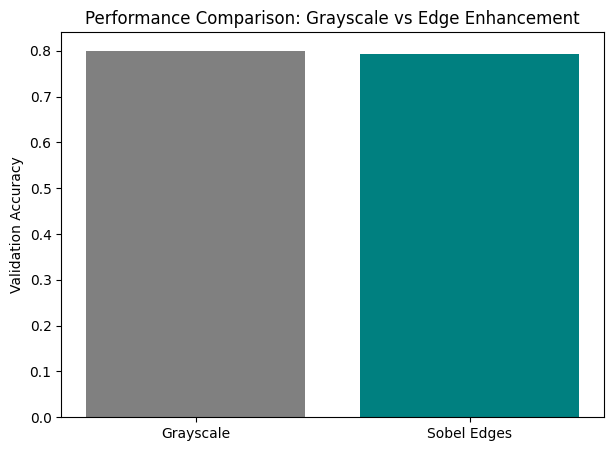

In [ ]:
# Get metrics from previous run (Before Edges)
prev_data = model_metrics["Medium_CNN"]
prev_acc = prev_data['history'].history['val_accuracy'][-1]

# Get metrics from current run (After Edges)
edge_acc = edge_history.history['val_accuracy'][-1]

comparison_results = {
    "Architecture": ["Medium_CNN (Grayscale)", "Medium_CNN (Sobel Edges)"],
    "Val Accuracy": [f"{prev_acc:.4f}", f"{edge_acc:.4f}"],
    "Training Time": [f"{prev_data['train_time']:.2f}s", f"{edge_train_time:.2f}s"]
}

# Display Table
import pandas as pd
print("\n" + "="*60)
print(" IMPACT OF EDGE ENHANCEMENT")
print("="*60)
print(pd.DataFrame(comparison_results).to_string(index=False))

# Plot Comparison
plt.figure(figsize=(7, 5))
plt.bar(['Grayscale', 'Sobel Edges'], [prev_acc, edge_acc], color=['gray', 'teal'])
plt.title('Performance Comparison: Grayscale vs Edge Enhancement')
plt.ylabel('Validation Accuracy')
plt.show()

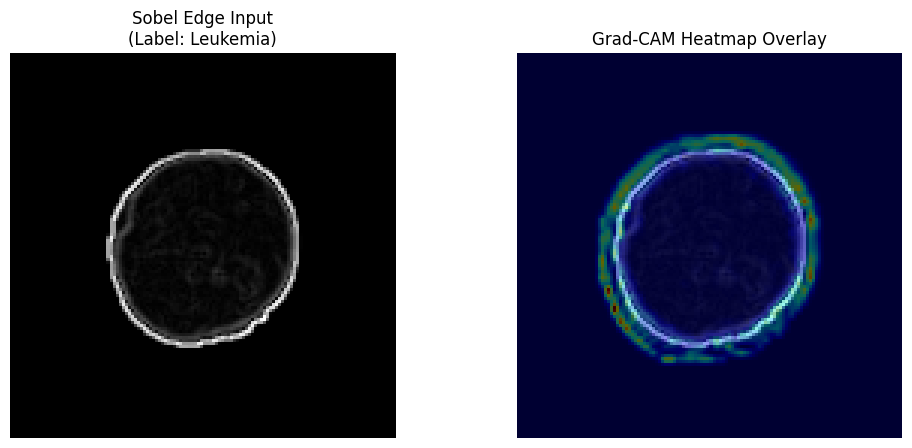

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def generate_grad_cam(img_tensor, model, last_conv_layer_name):
    # Ensure the model is built by calling it with a dummy input
    # This is often needed for Sequential models when constructing new functional models from them
    if not model.built:
        # Use a dummy input with the expected shape (batch_size=1, IMG_SIZE, IMG_SIZE, 1 channel for grayscale)
        dummy_input = tf.zeros((1, 128, 128, 1), dtype=img_tensor.dtype)
        _ = model(dummy_input)

    # 1. Setup the last conv layer and the prediction layer
    last_conv_layer = model.get_layer(last_conv_layer_name)

    # 2. Re-build a functional model from the inputs to the desired outputs
    # This avoids the "layer not called" error by linking them explicitly
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[last_conv_layer.output, model.layers[-1].output] # Changed model.output to model.layers[-1].output
    )

    # 3. Use GradientTape to monitor the forward pass
    with tf.GradientTape() as tape:
        # Ensure the input is float32
        img_tensor = tf.cast(img_tensor, tf.float32)
        last_conv_layer_output, preds = grad_model(img_tensor)

        # Target the specific prediction (since it's binary sigmoid, it's index 0)
        # We use the prediction value directly as the "loss"
        class_channel = preds[:, 0]

    # 4. Calculate gradients of the output w.r.t. the last conv layer feature map
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # 5. Mean intensity of the gradient per feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 6. Multiply each channel in the feature map by its importance
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 7. ReLU and Normalization
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

# --- Execution ---

# Grab a sample (Edge-enhanced version)
for images, labels in val_ds_edge.take(1):
    sample_img = images[0]
    sample_label = labels[0].numpy()
    break

# Prepare input
img_input = tf.expand_dims(sample_img, axis=0)

# IMPORTANT: Check layer names to be 100% sure
# final_edge_model.summary()
# Usually for build_model_2, the last conv is 'conv2d_1'
last_conv_layer = [l.name for l in final_edge_model.layers if 'conv2d' in l.name][-1]

# Run the fixed function
heatmap = generate_grad_cam(img_input, final_edge_model, last_conv_layer)

# --- Visualization ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title(f"Sobel Edge Input\n(Label: {'Leukemia' if sample_label==1 else 'Healthy'})")
plt.imshow(sample_img[:, :, 0], cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Grad-CAM Heatmap Overlay")
plt.imshow(sample_img[:, :, 0], cmap='gray')
# Resizing heatmap to match input size (128x128)
import cv2
heatmap_resized = cv2.resize(heatmap, (128, 128))
plt.imshow(heatmap_resized, cmap='jet', alpha=0.4)
plt.axis('off')

plt.show()

# **CNN Architecture**

In [8]:
model = models.Sequential([
    # Rescale pixel values from [0, 255] to [0, 1]
    layers.Rescaling(1./255, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Prevents overfitting
    layers.Dense(1, activation='sigmoid') # Binary output: 0 (Healthy) or 1 (ALL)
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

## **VGG16**

In [9]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

# Load the base VGG16 model (excluding the top dense layers)
base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# Freeze the base model to keep pre-trained features
base_vgg.trainable = False

vgg_model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    base_vgg,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

vgg_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


## **ResNet50**

In [10]:
from tensorflow.keras.applications import ResNet50

# Load ResNet50 base
base_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# Freeze base layers
base_resnet.trainable = False

resnet_model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    base_resnet,
    layers.GlobalAveragePooling2D(), # Better for ResNet than Flatten
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

resnet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


## **Evaluation & Inference Timing**

In [11]:
import time

# List of your models for easy iteration
model_list = {
    "Simple_CNN": model,
    "VGG16": vgg_model,
    "ResNet50": resnet_model
}

# Dictionary to store results
histories = {}
training_times = {}

for name, m in model_list.items():
    print(f"\n--- Starting Training: {name} ---")

    start_train = time.time()

    # Train the specific model
    histories[name] = m.fit(
        train_ds,
        validation_data=val_ds,
        epochs=15
    )

    elapsed = time.time() - start_train
    training_times[name] = elapsed

    print(f"[INFO] {name} Training Time: {elapsed:.2f} seconds")

# Final Summary Table
print("\n" + "="*30)
print("FINAL TRAINING SUMMARY")
print("="*30)
for name, duration in training_times.items():
    print(f"{name:12} | {duration:>7.2f} seconds")


--- Starting Training: Simple_CNN ---
Epoch 1/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 24s 85ms/step - accuracy: 0.8234 - loss: 0.4319 - precision: 0.7693 - recall: 0.6401 - val_accuracy: 0.8115 - val_loss: 0.4326 - val_precision: 0.8171 - val_recall: 0.5813
Epoch 2/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8426 - loss: 0.3997 - precision: 0.8034 - recall: 0.6728 - val_accuracy: 0.8282 - val_loss: 0.4056 - val_precision: 0.7662 - val_recall: 0.7195
Epoch 3/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8482 - loss: 0.3817 - precision: 0.8122 - recall: 0.6838 - val_accuracy: 0.8268 - val_loss: 0.3958 - val_precision: 0.7850 - val_recall: 0.6829
Epoch 4/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8457 - loss: 0.3723 - precision: 0.8154 - recall: 0.6696 - val_accuracy: 0.8254 - val_loss: 0.4024 - val_precision: 0.7895 - val_recall: 0.6707
Epoch 5/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8524 - loss: 0.3602 - precision: 0.8167 - recall: 0.6947 - 


MODEL TRAINING HISTORY PLOTS


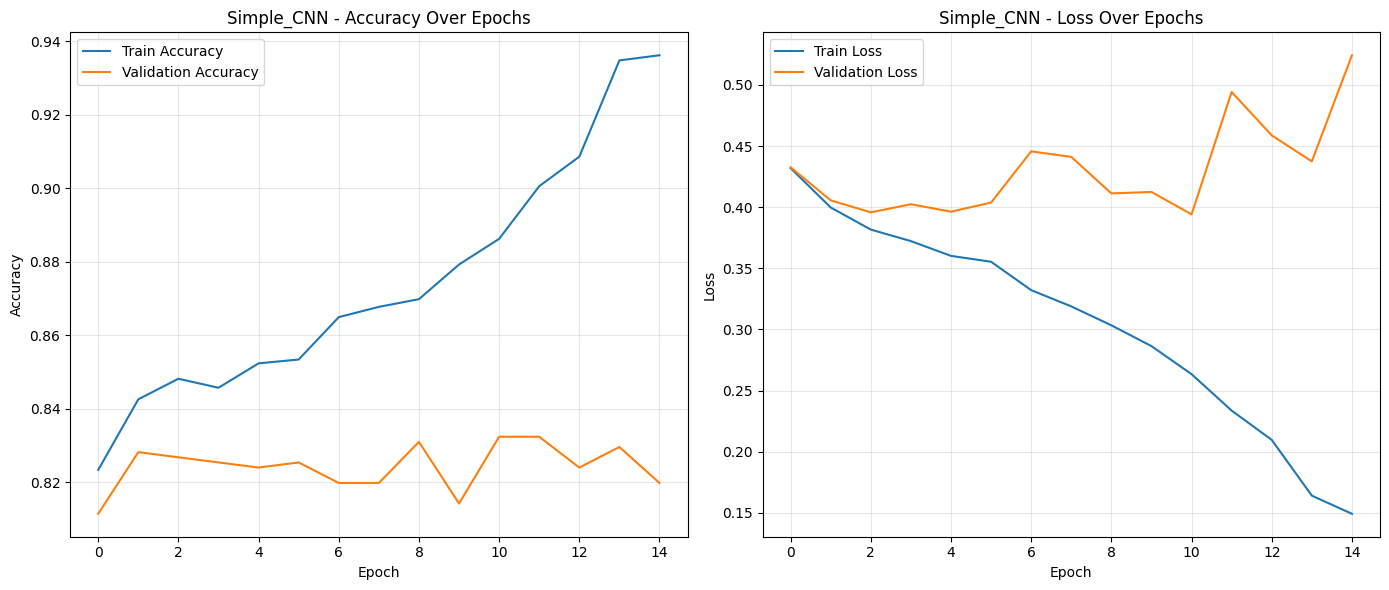

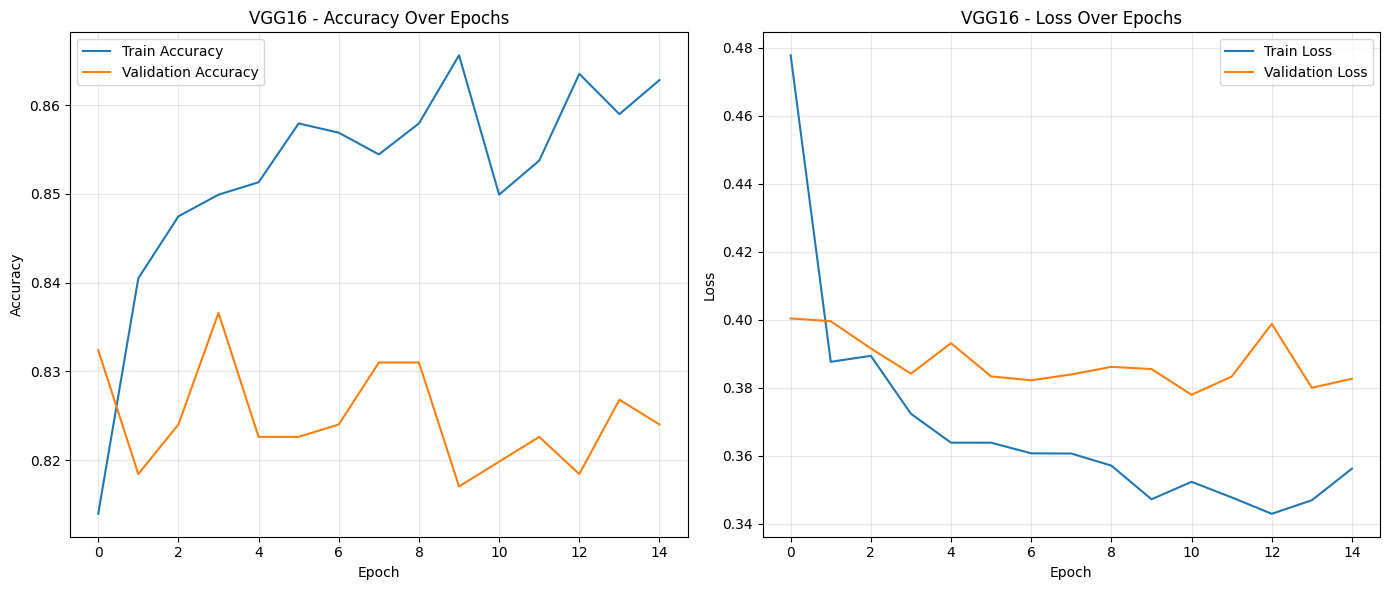

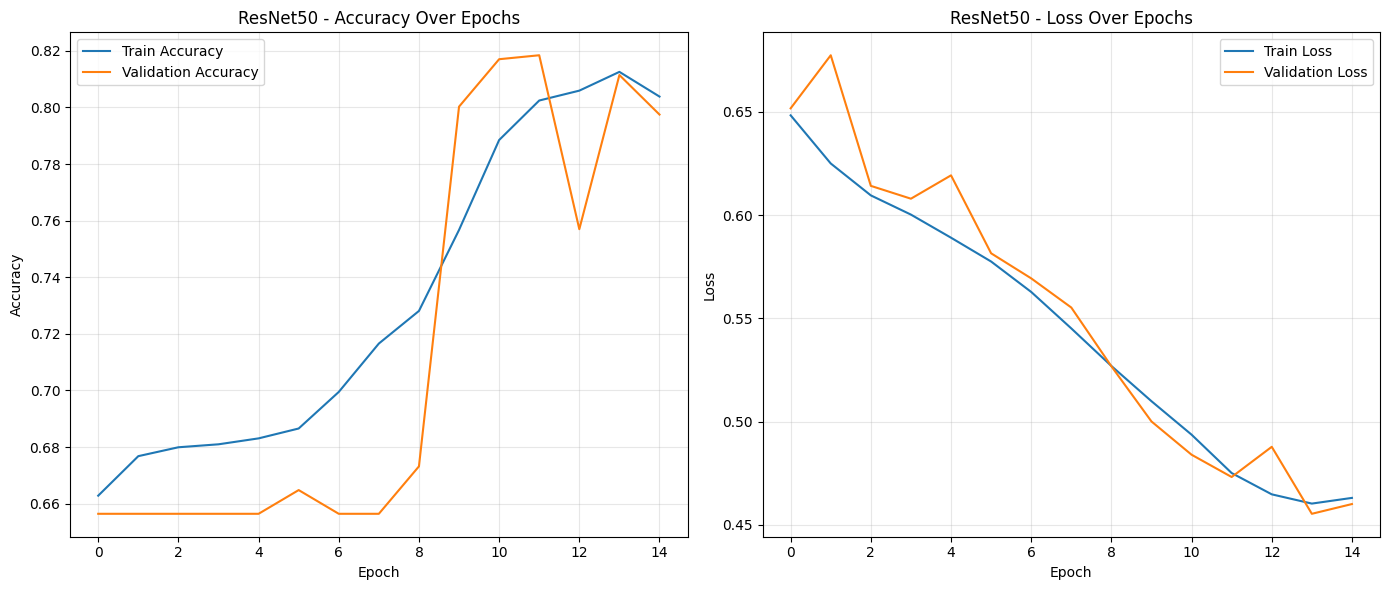


--- Calculating metrics for: Simple_CNN ---

--- Calculating metrics for: VGG16 ---

--- Calculating metrics for: ResNet50 ---

COMPREHENSIVE MODEL PERFORMANCE COMPARISON TABLE
     Model Accuracy Precision Recall F1-Score    AUC Training Time (s) Inference Time (s)
Simple_CNN   0.8198    0.8174 0.8198   0.8180 0.8812             45.65               1.22
     VGG16   0.8240    0.8319 0.8240   0.8128 0.8962            133.90               2.59
  ResNet50   0.7975    0.8097 0.7975   0.7797 0.8692             76.87               9.10


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # for better looking plots
from sklearn.metrics import classification_report, roc_curve, auc

# --- 1. Plotting History Graphs for Each Model ---
print("\n" + "="*50)
print("MODEL TRAINING HISTORY PLOTS")
print("="*50)
for name, history in histories.items():
    plt.figure(figsize=(14, 6))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{name} - Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{name} - Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# --- 2. Prepare for Comprehensive Summary Table ---
# Get true labels from the validation dataset
y_true_all = np.concatenate([y for x, y in val_ds], axis=0)

summary_data = []

# --- 3. Iterate Models, Calculate Metrics, and Store Data ---
for name, m in model_list.items():
    print(f"\n--- Calculating metrics for: {name} ---")

    # Calculate Inference Time
    start_test = time.time()
    y_pred_prob = m.predict(val_ds, verbose=0).ravel()
    test_time = time.time() - start_test

    y_pred = (y_pred_prob > 0.5).astype(int)

    # Get Classification Report and AUC
    report = classification_report(y_true_all, y_pred, output_dict=True, target_names=['Healthy', 'ALL'])
    fpr, tpr, _ = roc_curve(y_true_all, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    # Extract relevant metrics
    precision = report['weighted avg']['precision']
    recall = report['weighted avg']['recall']
    f1_score = report['weighted avg']['f1-score']
    accuracy = report['accuracy'] # Overall accuracy

    summary_data.append({
        "Model": name,
        "Accuracy": f"{accuracy:.4f}",
        "Precision": f"{precision:.4f}",
        "Recall": f"{recall:.4f}",
        "F1-Score": f"{f1_score:.4f}",
        "AUC": f"{roc_auc:.4f}",
        "Training Time (s)": f"{training_times[name]:.2f}",
        "Inference Time (s)": f"{test_time:.2f}"
    })

# --- 4. Create and Print Summary Table ---
comparison_df = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("COMPREHENSIVE MODEL PERFORMANCE COMPARISON TABLE")
print("="*80)
print(comparison_df.to_string(index=False))


## **Metrics & Visualizations**


==================== Evaluating Simple_CNN ====================
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
              precision    recall  f1-score   support

     Healthy       0.85      0.88      0.87       470
         ALL       0.76      0.70      0.73       246

    accuracy                           0.82       716
   macro avg       0.80      0.79      0.80       716
weighted avg       0.82      0.82      0.82       716


==================== Evaluating VGG16 ====================
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
              precision    recall  f1-score   support

     Healthy       0.81      0.96      0.88       470
         ALL       0.88      0.57      0.69       246

    accuracy                           0.82       716
   macro avg       0.84      0.76      0.78       716
weighted avg       0.83      0.82      0.81       716


==================== Evaluating ResNet50 ====================
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
              precision    recall  f1-s

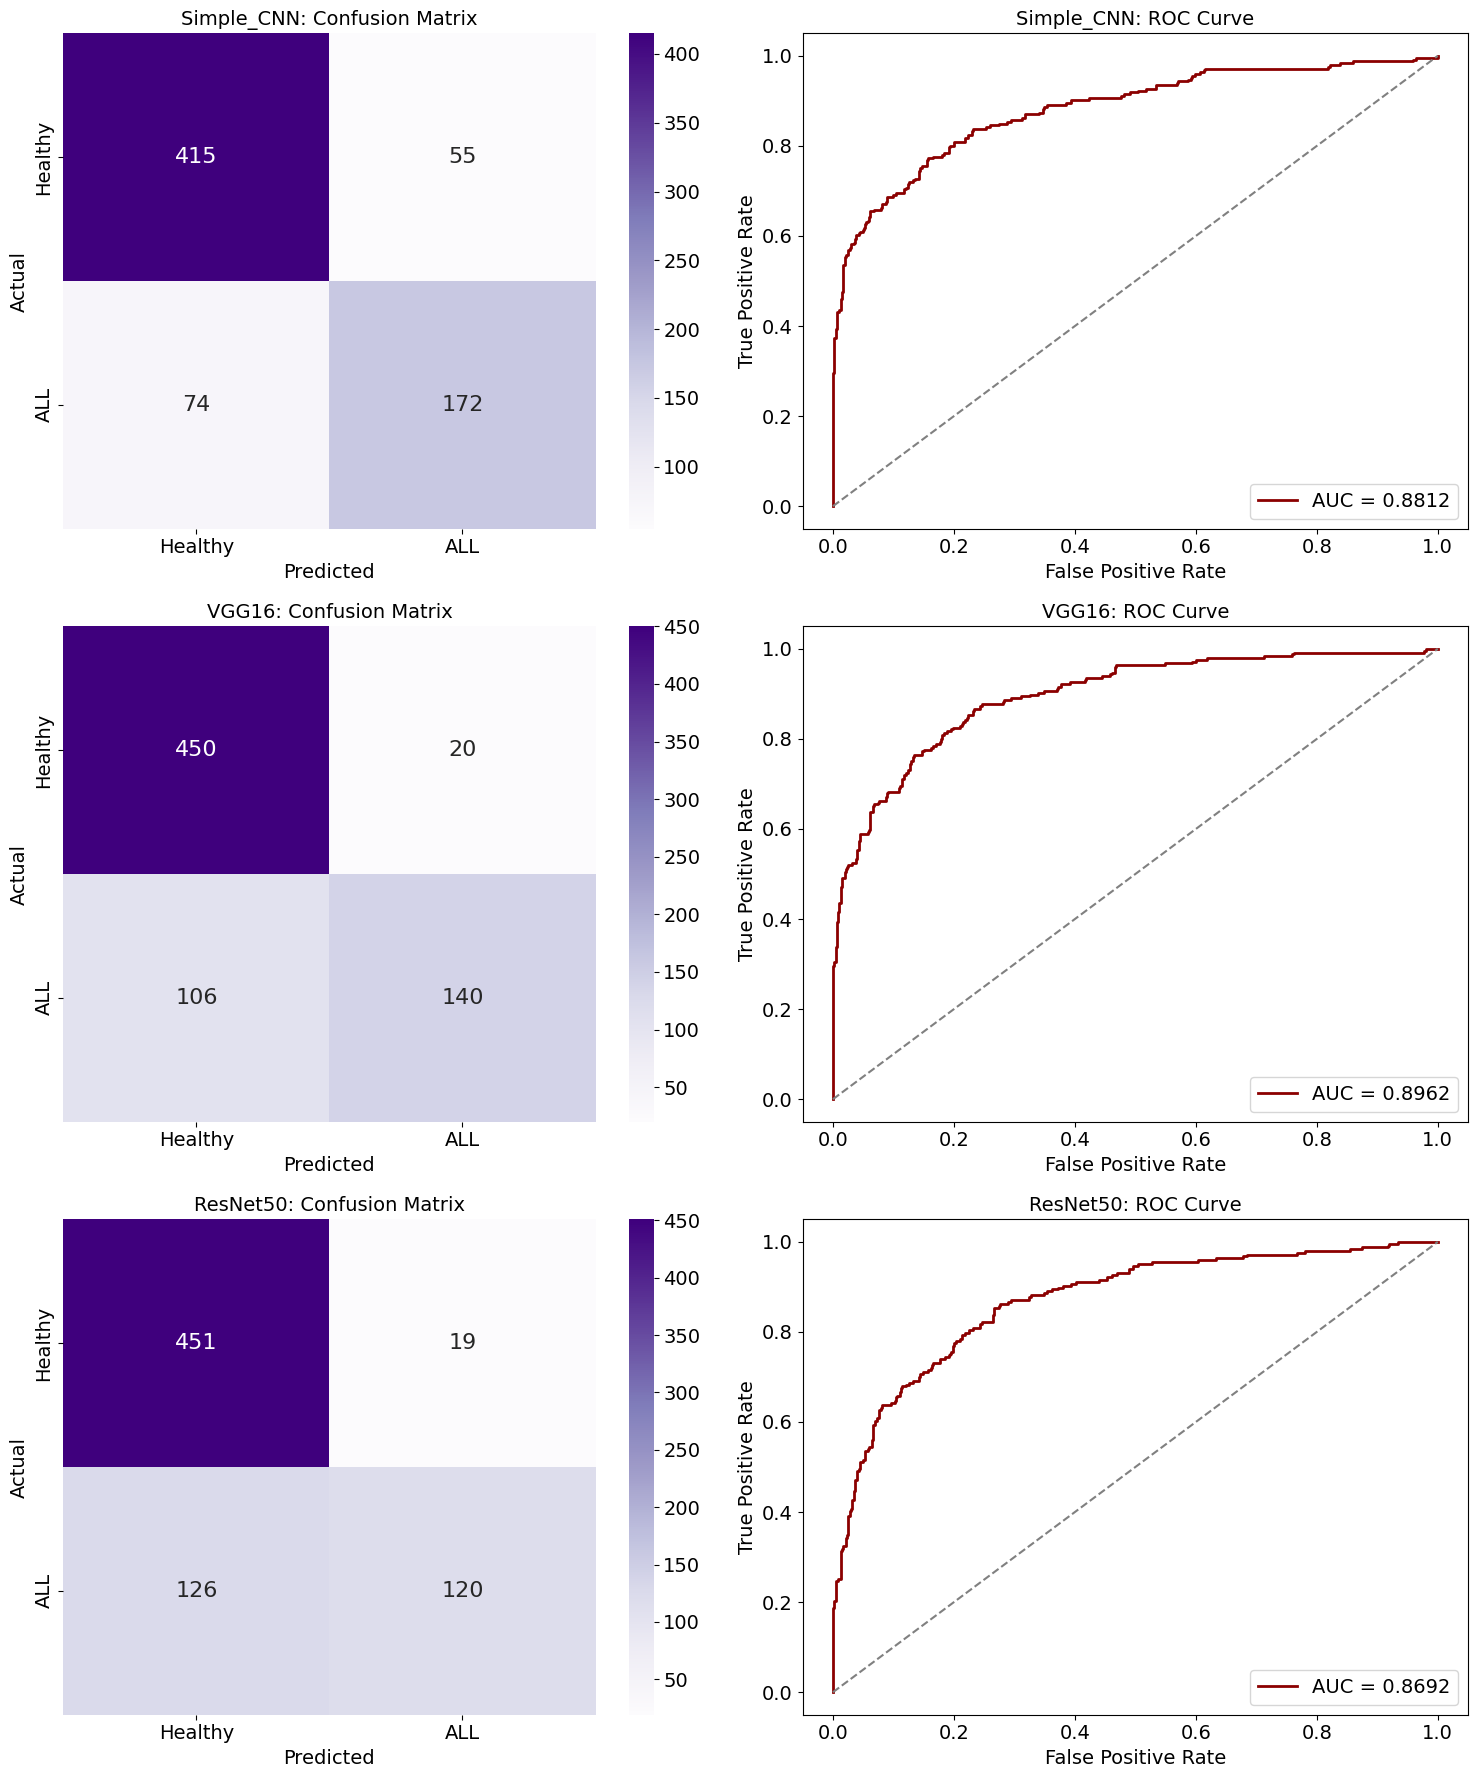

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Set a global font size for better readability
plt.rcParams.update({'font.size': 14}) # Base font size

# 1. Prepare Ground Truth Labels
# We take all labels from the validation dataset once
y_true = np.concatenate([y for x, y in val_ds], axis=0)

# 2. Setup Plotting
fig, axes = plt.subplots(len(model_list), 2, figsize=(15, 6 * len(model_list)))

for i, (name, m) in enumerate(model_list.items()):
    print(f"\n{'='*20} Evaluating {name} {'='*20}")

    # Generate Predictions
    y_pred_prob = m.predict(val_ds).ravel()
    y_pred = (y_pred_prob > 0.5).astype(int)

    # Print Text Metrics
    print(classification_report(y_true, y_pred, target_names=['Healthy', 'ALL']))

    # --- Plot 1: Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[i, 0],
                xticklabels=['Healthy', 'ALL'], yticklabels=['Healthy', 'ALL'], annot_kws={
                    'fontsize': 16
                })
    axes[i, 0].set_title(f'{name}: Confusion Matrix', fontsize=14)
    axes[i, 0].set_ylabel('Actual', fontsize=14)
    axes[i, 0].set_xlabel('Predicted', fontsize=14)
    axes[i, 0].tick_params(axis='x', labelsize=14)
    axes[i, 0].tick_params(axis='y', labelsize=14)

    # --- Plot 2: ROC Curve ---
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    axes[i, 1].plot(fpr, tpr, color='darkred', lw=2, label=f'AUC = {roc_auc:.4f}')
    axes[i, 1].plot([0, 1], [0, 1], color='gray', linestyle='--')
    axes[i, 1].set_title(f'{name}: ROC Curve', fontsize=14)
    axes[i, 1].set_xlabel('False Positive Rate', fontsize=14)
    axes[i, 1].set_ylabel('True Positive Rate', fontsize=14)
    axes[i, 1].legend(loc="lower right", fontsize=14)
    axes[i, 1].tick_params(axis='x', labelsize=14)
    axes[i, 1].tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()


# **Sobel edge enhancement**

In [14]:
import tensorflow as tf
import numpy as np

def process_pipeline_with_edges(file_path, label):
    # 1. Read and decode
    img = tf.io.read_file(file_path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)

    # 2. Resize and Grayscale
    img = tf.image.resize(img, (128, 128))
    img = tf.image.rgb_to_grayscale(img)

    # 3. Edge Enhancement (Sobel Filter)
    img_batch = tf.expand_dims(img, 0)
    edges = tf.image.sobel_edges(img_batch)
    img = tf.reduce_sum(tf.abs(edges), axis=-1)[0]

    # 4. Normalize and set explicit shape
    img = tf.cast(img, tf.float32) / 255.0
    img.set_shape([128, 128, 1])

    return img, label

# Create the Edge-Enhanced Datasets
train_ds_edge = tf.data.Dataset.from_tensor_slices((list(train_files), list(train_labels))) \
                .map(process_pipeline_with_edges).batch(32).prefetch(tf.data.AUTOTUNE)

val_ds_edge = tf.data.Dataset.from_tensor_slices((list(val_files), list(val_labels))) \
              .map(process_pipeline_with_edges).batch(32).prefetch(tf.data.AUTOTUNE)

In [15]:
from tensorflow.keras import layers, models

# Using your specific architecture structure
model = models.Sequential([
    # Input shape updated to 1 channel for edge-enhanced images
    # Rescaling removed here as it is handled in the preprocessing function
    layers.Input(shape=(128, 128, 1)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Prevents overfitting
    layers.Dense(1, activation='sigmoid') # Binary output: 0 (Healthy) or 1 (ALL)
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
import time

print("--- Starting Training: Edge-Enhanced CNN ---")
start_time = time.time()

history = model.fit(
    train_ds_edge,
    validation_data=val_ds_edge,
    epochs=15
)

print(f"\n[INFO] Training complete. Total time: {time.time() - start_time:.2f} seconds")

--- Starting Training: Edge-Enhanced CNN ---
Epoch 1/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 26s 321ms/step - accuracy: 0.8011 - loss: 0.4726 - precision: 0.7843 - recall: 0.8330 - val_accuracy: 0.8133 - val_loss: 0.4749 - val_precision: 0.8622 - val_recall: 0.7380
Epoch 2/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 25s 124ms/step - accuracy: 0.8118 - loss: 0.4471 - precision: 0.7863 - recall: 0.8587 - val_accuracy: 0.8176 - val_loss: 0.4526 - val_precision: 0.8600 - val_recall: 0.7511
Epoch 3/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 143ms/step - accuracy: 0.8188 - loss: 0.4322 - precision: 0.7924 - recall: 0.8662 - val_accuracy: 0.8176 - val_loss: 0.4556 - val_precision: 0.8564 - val_recall: 0.7555
Epoch 4/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 142ms/step - accuracy: 0.8258 - loss: 0.4123 - precision: 0.7973 - recall: 0.8758 - val_accuracy: 0.8176 - val_loss: 0.4495 - val_precision: 0.8564 - val_recall: 0.7555
Epoch 5/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step - accuracy: 0.8328 - loss: 0.3944 - precision: 0.8081 - recal

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step

==================== EVALUATION REPORT ====================
              precision    recall  f1-score   support

     Healthy       0.81      0.83      0.82       237
         ALL       0.82      0.80      0.81       229

    accuracy                           0.82       466
   macro avg       0.82      0.82      0.82       466
weighted avg       0.82      0.82      0.82       466



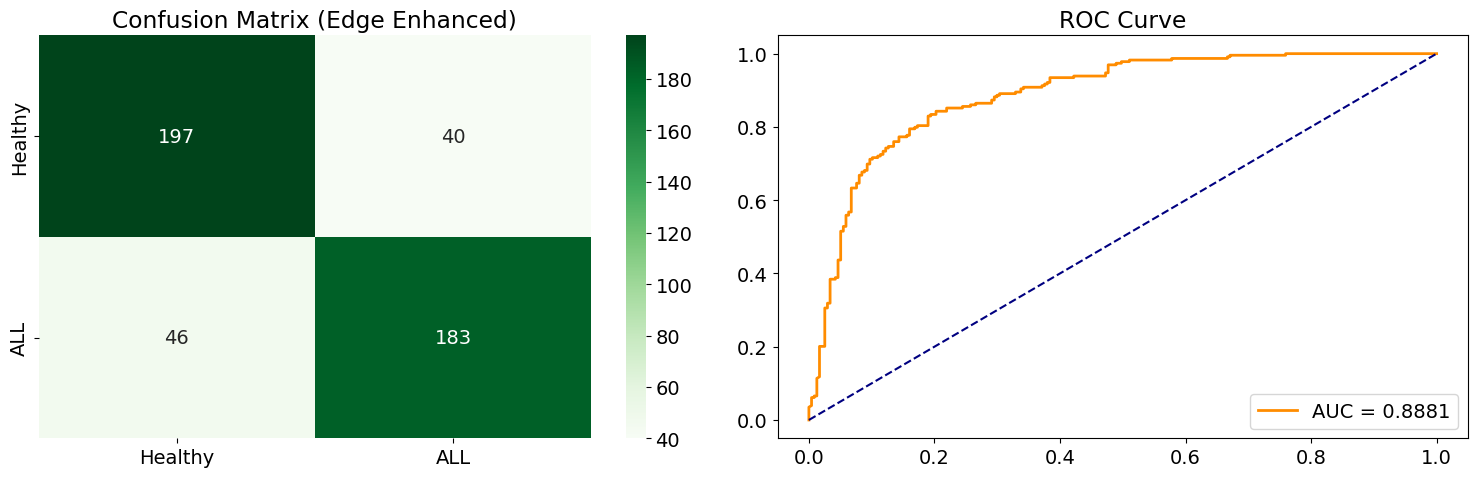

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# 1. Generate Predictions
y_true = np.concatenate([y for x, y in val_ds_edge], axis=0)
y_pred_prob = model.predict(val_ds_edge).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

# 2. Classification Report
print("\n" + "="*20 + " EVALUATION REPORT " + "="*20)
print(classification_report(y_true, y_pred, target_names=['Healthy', 'ALL']))

# 3. Visualizations
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax[0],
            xticklabels=['Healthy', 'ALL'], yticklabels=['Healthy', 'ALL'])
ax[0].set_title('Confusion Matrix (Edge Enhanced)')

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc(fpr, tpr):.4f}')
ax[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
ax[1].set_title('ROC Curve')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# **Model Explainability using Grad-Cam**

In [28]:
import tensorflow as tf
import numpy as np

# 1. Check if model exists and is built
# We send a dummy tensor of (1, 128, 128, 1) through it
dummy_input = tf.random.uniform((1, 128, 128, 1))
output = model(dummy_input)

print(f"Model successfully called. Output shape: {output.shape}")
print(f"Final layer name: {model.layers[-1].name}")

# Identify the last Conv2D layer automatically
conv_layers = [l.name for l in model.layers if isinstance(l, tf.keras.layers.Conv2D)]
last_conv_layer_name = conv_layers[-1]
print(f"Targeting layer for Grad-CAM: {last_conv_layer_name}")

Model successfully called. Output shape: (1, 1)
Final layer name: dense_7
Targeting layer for Grad-CAM: conv2d_5


In [31]:
import tensorflow as tf

def get_gradcam_model(model, last_conv_layer_name):
    # 1. Access the specific input of the model
    # We use model.input_shape to create a symbolic input if model.input is missing
    img_input = tf.keras.Input(shape=(128, 128, 1))

    # 2. Re-trace the model's path manually to ensure nodes are created
    x = img_input
    target_conv_layer_output = None

    # We loop through layers to find the one we need
    for layer in model.layers:
        x = layer(x)
        if layer.name == last_conv_layer_name:
            target_conv_layer_output = x

    # 3. Create the functional model
    # Inputs: our new symbolic input | Outputs: [target conv layer, final prediction]
    return tf.keras.models.Model(inputs=img_input, outputs=[target_conv_layer_output, x])

# --- EXECUTION ---
# Ensure 'last_conv_layer_name' was defined in Step 1 (usually 'conv2d_5')
grad_model = get_gradcam_model(model, last_conv_layer_name)

# Test it with dummy data to make sure it's alive
dummy_input = tf.random.uniform((1, 128, 128, 1))
conv_outs, preds = grad_model(dummy_input)

print(f"Success! Grad-model created.")
print(f"Conv output shape: {conv_outs.shape}")

Success! Grad-model created.
Conv output shape: (1, 28, 28, 128)


In [32]:
import numpy as np
import cv2

def compute_heatmap(grad_model, img_array):
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        # Target the probability of the positive class (Leukemia)
        loss = predictions[:, 0]

    # Gradients of the output with respect to the conv layer
    grads = tape.gradient(loss, conv_outputs)

    # Global Average Pooling
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weighting
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # ReLU and Normalize
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

# Get a real sample
sample_img_path = val_files.iloc[0]
img_tensor, _ = process_pipeline_with_edges(sample_img_path, 0)
img_array = tf.expand_dims(img_tensor, axis=0)

heatmap = compute_heatmap(grad_model, img_array)
print("Heatmap generated!")

Heatmap generated!


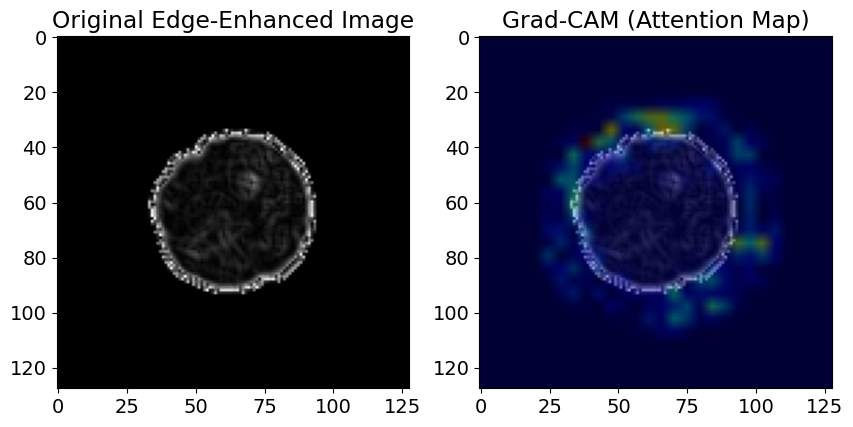

In [33]:
import matplotlib.pyplot as plt

def show_gradcam_results(heatmap, img_tensor):
    # Prepare color overlay
    heatmap = np.uint8(255 * heatmap)
    jet = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    jet = cv2.resize(jet, (128, 128))

    # Overlay
    original = np.uint8(255 * img_tensor.numpy())
    original_bgr = cv2.cvtColor(original, cv2.COLOR_GRAY2BGR)
    overlayed = cv2.addWeighted(original_bgr, 0.6, jet, 0.4, 0)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(original, cmap='gray')
    plt.title("Original Edge-Enhanced Image")

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(overlayed, cv2.COLOR_BGR2RGB))
    plt.title("Grad-CAM (Attention Map)")
    plt.show()

show_gradcam_results(heatmap, img_tensor)

# **Save and Download Assets for Streamlit Application**

In [35]:
import os
import json

# 1. Save the trained model
# Using .keras format is recommended for newer TensorFlow versions
model.save('leukemia_edge_model.h5')

# 2. Create a requirements.txt file automatically
requirements = """
streamlit
tensorflow
numpy
opencv-python-headless
Pillow
scikit-learn
"""
with open('requirements.txt', 'w') as f:
    f.write(requirements.strip())

# 3. Download the files to your computer
from google.colab import files
files.download('leukemia_edge_model.h5')
files.download('requirements.txt')

print("Files saved and download triggered!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Files saved and download triggered!
